##Sign Language video Translation to english and Translation to three Indian languages

Package Installation

In [ ]:
!pip install pyngrok --quiet

In [ ]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 9.4 MB/s eta 0:00:00


In [ ]:
!pip install torch torchvision transformers decord scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 66.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

In [ ]:
!pip install -q transformers decord

In [ ]:
!pip install sentencepiece

In [ ]:
!pip install opencv-python Pillow -q

In [ ]:
!pip install localtunnel -q

ERROR: Could not find a version that satisfies the requirement localtunnel (from versions: none)
ERROR: No matching distribution found for localtunnel


Read sign language dataset

In [ ]:
# STEP 1: Mount Google Drive
from google.colab import drive
import os

drive.mount('/content/drive')
data_dir = "/content/drive/MyDrive/Adjectives"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls -l $data_dir

total 52
drwx------ 2 root root 4096 May 10 06:55 '1. loud'
drwx------ 2 root root 4096 May 10 06:55 '2. quiet'
drwx------ 2 root root 4096 May 18 13:52 '37. Hat'
drwx------ 2 root root 4096 May 18 13:53 '38. Dress'
drwx------ 2 root root 4096 May 18 13:53 '39. Suit'
drwx------ 2 root root 4096 May 10 06:55 '3. happy'
drwx------ 2 root root 4096 May 18 13:53 '40. Skirt'
drwx------ 2 root root 4096 May 18 13:53 '41. Shirt'
drwx------ 2 root root 4096 May 10 06:55 '4. sad'
drwx------ 2 root root 4096 May 10 06:55 '5. Beautiful'
drwx------ 2 root root 4096 May 10 06:55 '6. Ugly'
drwx------ 2 root root 4096 May 10 06:55 '7. Deaf'
drwx------ 2 root root 4096 May 10 06:55 '8. Blind'


In [ ]:
import os
import cv2
import torch
import random
import numpy as np
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from transformers import VideoMAEForVideoClassification, VideoMAEFeatureExtractor

dataset loading and video processing

In [ ]:
# Step 1: Dataset Class
class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, transform=None, num_frames=16):
        self.video_paths = video_paths
        self.labels = labels
        self.transform = transform
        self.num_frames = num_frames

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        frames = self.extract_frames(video_path, self.num_frames)
        if self.transform:
            frames = [self.transform(frame) for frame in frames]
        frames = torch.stack(frames).permute(1, 0, 2, 3)  # (3, num_frames, H, W)
        label = self.labels[idx]
        return frames, label

    def extract_frames(self, video_path, num_frames):
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames == 0:
            raise ValueError(f"Video {video_path} has 0 frames")

        step = max(total_frames // num_frames, 1)
        frames = []

        for i in range(0, total_frames, step):
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()
            if not ret:
                continue
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = Image.fromarray(frame)
            frames.append(frame)
            if len(frames) == num_frames:
                break

        cap.release()

        # Pad with last frame if not enough
        while len(frames) < num_frames:
            frames.append(frames[-1])

        return frames

In [ ]:
# Step 2: Load Data from Folder Structure
def load_dataset_from_folders(root_dir):
    video_paths = []
    labels = []
    for label_name in os.listdir(root_dir):
        label_path = os.path.join(root_dir, label_name)
        if not os.path.isdir(label_path):
            continue
        for video_file in os.listdir(label_path):
            if video_file.endswith(".MOV") or video_file.endswith(".mp4"):
                video_paths.append(os.path.join(label_path, video_file))
                labels.append(label_name)
    return video_paths, labels


feature extractor

In [ ]:
# Step 3: Label Encoding
root_dir = "/content/drive/MyDrive/Adjectives"
video_paths, labels = load_dataset_from_folders(root_dir)
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
print("Training le.classes_:", list(le.classes_))

# Step 4: Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

Training le.classes_: [np.str_('1. loud'), np.str_('2. quiet'), np.str_('3. happy'), np.str_('37. Hat'), np.str_('38. Dress'), np.str_('39. Suit'), np.str_('4. sad'), np.str_('40. Skirt'), np.str_('41. Shirt'), np.str_('5. Beautiful'), np.str_('6. Ugly'), np.str_('7. Deaf'), np.str_('8. Blind')]


training loop

In [ ]:
from sklearn.model_selection import train_test_split

# Split into train and validation
train_paths, val_paths, train_labels, val_labels = train_test_split(
    video_paths, labels_encoded, test_size=0.2, random_state=42, stratify=labels_encoded
)


In [ ]:
# Step 5: Dataset & Dataloader
train_dataset = VideoDataset(train_paths, train_labels, transform=transform)
val_dataset = VideoDataset(val_paths, val_labels, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)

HK_TOKEN=os.getenv("HK_TOKEN")

# Step 6: Load Pretrained Model
model = VideoMAEForVideoClassification.from_pretrained("MCG-NJU/videomae-base",token=HK_TOKEN)
model.classifier = torch.nn.Linear(model.classifier.in_features, len(le.classes_))
model.train()
model.cuda()

config.json:   0%|          | 0.00/725 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/377M [00:00<?, ?B/s]

Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at MCG-NJU/videomae-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


VideoMAEForVideoClassification(
  (videomae): VideoMAEModel(
    (embeddings): VideoMAEEmbeddings(
      (patch_embeddings): VideoMAEPatchEmbeddings(
        (projection): Conv3d(3, 768, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
    )
    (encoder): VideoMAEEncoder(
      (layer): ModuleList(
        (0-11): 12 x VideoMAELayer(
          (attention): VideoMAEAttention(
            (attention): VideoMAESelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): VideoMAESelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): VideoMAEIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
    

training

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
# from tqdm.notebook import tqdm
from torch.amp import autocast, GradScaler

EPOCHS=15

# Define cuda Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# --- Optimizer and Loss Function ---
optimizer = optim.AdamW(model.parameters(), lr=1e-5) # AdamW is good for transformers
loss_fn = nn.CrossEntropyLoss()
scaler = GradScaler(enabled=(DEVICE.type == 'cuda')) # For mixed-precision

print(f"\nStarting training for {EPOCHS} epochs on {DEVICE}...")
if hasattr(model, 'config') and hasattr(model.config, 'num_channels'):
    print(f"Model expected num_channels: {model.config.num_channels}")
else:
    print("Warning: Could not determine model.config.num_channels. Assuming 3.")


for epoch in range(EPOCHS):
    # --- Training Phase ---
    model.train()
    running_train_loss = 0.0
    correct_train_predictions = 0
    total_train_samples = 0

    # progress_bar_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)
    # for batch_idx, batch in enumerate(progress_bar_train):
    for batch_idx, batch in enumerate(train_loader):
        videos, labels = batch
        videos = videos.to(DEVICE)
        labels = labels.to(DEVICE)

        # --- Shape Check and Permutation for VideoMAE ---
        # VideoMAE's `pixel_values` argument expects (B, T, C, H, W)
        # Its internal embedding layer permutes this to (B, C, T, H, W)
        if batch_idx == 0 and epoch == 0: # Print shape info only once
            print(f"Original video shape from DataLoader: {videos.shape} (expected B, T, C, H, W or B, C, T, H, W)")

        current_shape = videos.shape
        expected_channels = getattr(model.config, 'num_channels', 3) # Default to 3 if not found

        if len(current_shape) == 5:
            # Case 1: Input is (B, C, T, H, W) but model expects (B, T, C, H, W) for pixel_values
            # This happens if C (e.g., 3) is at current_shape[1] and T is at current_shape[2]
            if current_shape[1] == expected_channels and current_shape[2] != expected_channels:
                if batch_idx == 0 and epoch == 0:
                    print(f"Permuting videos from (B,C,T,H,W) {current_shape} to (B,T,C,H,W)")
                videos = videos.permute(0, 2, 1, 3, 4) # B,C,T,H,W -> B,T,C,H,W
            # Case 2: Input is (B, T, H, W, C)
            elif current_shape[4] == expected_channels:
                if batch_idx == 0 and epoch == 0:
                    print(f"Permuting videos from (B,T,H,W,C) {current_shape} to (B,T,C,H,W)")
                videos = videos.permute(0, 1, 4, 2, 3) # B,T,H,W,C -> B,T,C,H,W
            elif current_shape[2] == expected_channels: # Assumed (B, T, C, H, W)
                 if batch_idx == 0 and epoch == 0:
                    print(f"Video shape {current_shape} is assumed (B,T,C,H,W) - correct for pixel_values.")
            elif batch_idx == 0 and epoch == 0:
                 print(f"Warning: Video shape {current_shape} doesn't match common patterns for auto-permutation. Ensure it's (B,T,C,H,W) for pixel_values.")
        elif batch_idx == 0 and epoch == 0:
            print(f"Warning: Video tensor does not have 5 dimensions. Shape is {current_shape}. Expected (B,T,C,H,W).")


        optimizer.zero_grad()

        with autocast(device_type=DEVICE.type, enabled=(DEVICE.type == 'cuda')): # Mixed precision
            outputs = model(pixel_values=videos).logits
            loss = loss_fn(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_train_loss += loss.item() * videos.size(0) # Weighted by batch size
        preds = torch.argmax(outputs, dim=1)
        correct_train_predictions += (preds == labels).sum().item()
        total_train_samples += labels.size(0)


    epoch_train_loss = running_train_loss / total_train_samples if total_train_samples > 0 else 0
    epoch_train_acc = correct_train_predictions / total_train_samples if total_train_samples > 0 else 0

    # --- Validation Phase ---
    model.eval()
    running_val_loss = 0.0
    correct_val_predictions = 0
    total_val_samples = 0

    with torch.no_grad():
        for batch in val_loader:
            videos, labels = batch
            videos = videos.to(DEVICE)
            labels = labels.to(DEVICE)

            # --- Shape Check and Permutation
            current_shape = videos.shape
            if len(current_shape) == 5:
                if current_shape[1] == expected_channels and current_shape[2] != expected_channels:
                    videos = videos.permute(0, 2, 1, 3, 4)
                elif current_shape[4] == expected_channels:
                    videos = videos.permute(0, 1, 4, 2, 3)

            with autocast(device_type=DEVICE.type, enabled=(DEVICE.type == 'cuda')):
                outputs = model(pixel_values=videos).logits
                loss = loss_fn(outputs, labels)

            running_val_loss += loss.item() * videos.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct_val_predictions += (preds == labels).sum().item()
            total_val_samples += labels.size(0)

    epoch_val_loss = running_val_loss / total_val_samples if total_val_samples > 0 else 0
    epoch_val_acc = correct_val_predictions / total_val_samples if total_val_samples > 0 else 0

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

# --- End of Training ---
print("\nTraining finished.")




Starting training for 15 epochs on cuda...
Model expected num_channels: 3
Original video shape from DataLoader: torch.Size([2, 3, 16, 224, 224]) (expected B, T, C, H, W or B, C, T, H, W)
Permuting videos from (B,C,T,H,W) torch.Size([2, 3, 16, 224, 224]) to (B,T,C,H,W)
Epoch 1/15 | Train Loss: 2.4150, Train Acc: 0.1410 | Val Loss: 2.1080, Val Acc: 0.2500
Epoch 2/15 | Train Loss: 1.9218, Train Acc: 0.2179 | Val Loss: 1.8429, Val Acc: 0.1000
Epoch 3/15 | Train Loss: 1.6652, Train Acc: 0.2756 | Val Loss: 1.7672, Val Acc: 0.1500
Epoch 4/15 | Train Loss: 1.5216, Train Acc: 0.3205 | Val Loss: 1.7041, Val Acc: 0.1750
Epoch 5/15 | Train Loss: 1.4160, Train Acc: 0.3654 | Val Loss: 1.7025, Val Acc: 0.1500
Epoch 6/15 | Train Loss: 1.3910, Train Acc: 0.4231 | Val Loss: 1.6938, Val Acc: 0.2000
Epoch 7/15 | Train Loss: 1.2574, Train Acc: 0.4872 | Val Loss: 1.6140, Val Acc: 0.2750
Epoch 8/15 | Train Loss: 0.9530, Train Acc: 0.7244 | Val Loss: 1.2369, Val Acc: 0.4750
Epoch 9/15 | Train Loss: 0.6113, T

In [ ]:
# Example: Save the final model
model_save_path = "videomae_final_model.pt"
torch.save(model.state_dict(), model_save_path)
print(f"Final model saved to {model_save_path}")

Final model saved to videomae_final_model.pt


Model Evaluation and metrics calculation

In [ ]:
# --- Function to Evaluate Model and Calculate Metrics ---
def evaluate_model(model_to_eval, data_loader, loss_function, device, label_encoder=None):
    model_to_eval.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for batch in data_loader:
            videos, labels = batch
            videos = videos.to(device)
            labels = labels.to(device)

            # --- Shape Check and Permutation
            current_shape = videos.shape
            if len(current_shape) == 5:
                if current_shape[1] == expected_channels and current_shape[2] != expected_channels:
                    videos = videos.permute(0, 2, 1, 3, 4)
                elif current_shape[4] == expected_channels:
                    videos = videos.permute(0, 1, 4, 2, 3)

            with autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                outputs = model_to_eval(pixel_values=videos).logits
                loss = loss_function(outputs, labels)

            running_loss += loss.item() * videos.size(0)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            correct_predictions += (preds == labels).sum().item()
            total_samples += labels.size(0)

    avg_loss = running_loss / total_samples if total_samples > 0 else 0
    accuracy = correct_predictions / total_samples if total_samples > 0 else 0

    print(f"\nEvaluation Results:")
    print(f"Average Loss: {avg_loss:.4f}")
    print(f"Accuracy: {accuracy:.4f} ({correct_predictions}/{total_samples})")

    if label_encoder and total_samples > 0:
        try:
            unique_true_labels = np.unique(all_labels)
            unique_pred_labels = np.unique(all_preds)

            max_label_val = max(unique_true_labels.max() if len(unique_true_labels) > 0 else -1,
                                unique_pred_labels.max() if len(unique_pred_labels) > 0 else -1)

            if max_label_val >= len(label_encoder.classes_):
                print(f"Warning: Max label value ({max_label_val}) is out of bounds for LabelEncoder (max index {len(label_encoder.classes_)-1}). Classification report might be problematic.")
                target_names_report = [str(i) for i in range(len(label_encoder.classes_))]
                present_labels = sorted(list(set(unique_true_labels) | set(unique_pred_labels)))
                if not all(pl < len(label_encoder.classes_) for pl in present_labels):
                     print("Some present labels are still out of bounds for LabelEncoder. Using string indices for report.")
                     target_names_report = [str(i) for i in present_labels]
                else:
                     target_names_report = [str(label_encoder.inverse_transform([i])[0]) if i < len(label_encoder.classes_) else f"UnknownLabel_{i}" for i in present_labels]

                print(classification_report(all_labels, all_preds, labels=present_labels, target_names=target_names_report, zero_division=0))

            else:
                present_labels = sorted(list(set(unique_true_labels) | set(unique_pred_labels)))
                target_names_report = [str(label_encoder.inverse_transform([i])[0]) for i in present_labels]
                print(classification_report(all_labels, all_preds, labels=present_labels, target_names=target_names_report, zero_division=0))

            # Confusion Matrix
            cm = confusion_matrix(all_labels, all_preds, labels=range(len(label_encoder.classes_)))
            plt.figure(figsize=(max(8, len(label_encoder.classes_)//1.5), max(6, len(label_encoder.classes_)//2)))
            sns.heatmap(cm, annot=True if len(label_encoder.classes_) <= 20 else False, fmt='d', cmap='Blues',
                        xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
            plt.xlabel('Predicted Label')
            plt.ylabel('True Label')
            plt.title(f'Confusion Matrix (Eval)')
            plt.xticks(rotation=90, fontsize=8); plt.yticks(rotation=0, fontsize=8)
            plt.tight_layout(); plt.show()

        except ValueError as e_report:
            print(f"Could not generate classification report or confusion matrix: {e_report}")
            print("This might happen if labels in test set are not in LabelEncoder's known classes, or if test set is empty for some classes.")
            print(f"Unique true labels: {np.unique(all_labels)}")
            print(f"Unique predicted labels: {np.unique(all_preds)}")


    return accuracy, avg_loss, all_preds, all_labels


--- Evaluating Final Model on Validation/Test Data ---

Evaluation Results:
Average Loss: 0.6808
Accuracy: 0.7750 (31/40)
              precision    recall  f1-score   support

     1. loud       1.00      1.00      1.00         4
    2. quiet       1.00      1.00      1.00         4
    3. happy       1.00      1.00      1.00         4
     37. Hat       1.00      0.75      0.86         4
   38. Dress       0.75      0.75      0.75         4
    39. Suit       0.80      1.00      0.89         4
      4. sad       0.50      1.00      0.67         1
   40. Skirt       1.00      1.00      1.00         4
   41. Shirt       0.75      0.75      0.75         4
5. Beautiful       0.00      0.00      0.00         1
     6. Ugly       0.50      0.50      0.50         2
     7. Deaf       0.00      0.00      0.00         2
    8. Blind       0.00      0.00      0.00         2

    accuracy                           0.78        40
   macro avg       0.64      0.67      0.65        40
weighted av

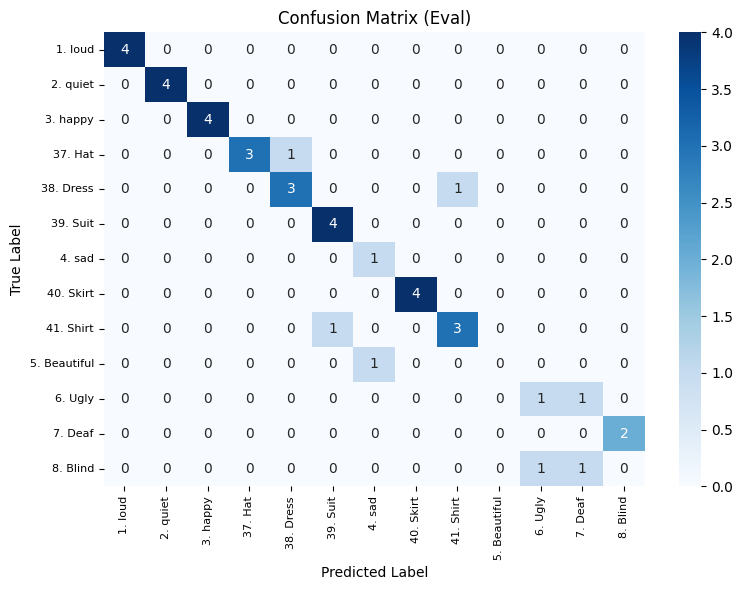

In [ ]:
# Import the necessary function
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
print("\n--- Evaluating Final Model on Validation/Test Data ---")
final_accuracy, final_loss, _, _ = evaluate_model(model, val_loader, loss_fn, DEVICE, label_encoder=le if 'le' in locals() else None)

Model Inference

In [ ]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset # For VideoDataset definition
from sklearn.preprocessing import LabelEncoder
from transformers import VideoMAEForVideoClassification # To define model architecture
from torch.amp import autocast # For mixed precision if used during training

# --- Configuration for Inference
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

HK_TOKEN=os.getenv("HK_TOKEN")

# --- Model & Data Specifics (MUST MATCH YOUR TRAINED MODEL) ---
MODEL_VARIANT = "MCG-NJU/videomae-base"
PATH_TO_SAVED_MODEL_WEIGHTS = "/content/videomae_final_model.pt"

YOUR_NUM_CLASSES = 13

NUM_FRAMES_FOR_INFERENCE = 16
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
# These normalization stats should be the same as used in your training transform
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD = [0.229, 0.224, 0.225]

# --- 1. Re-define your VideoDataset Class
class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, transform=None, num_frames=16):
        self.video_paths = video_paths
        self.labels = labels
        self.transform = transform
        self.num_frames = num_frames

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        frames_pil = self.extract_frames_pil(video_path, self.num_frames)

        if self.transform:
            frames_tensor = torch.stack([self.transform(frame) for frame in frames_pil])
        else:
            temp_transform = transforms.Compose([transforms.Resize((IMAGE_HEIGHT, IMAGE_WIDTH)), transforms.ToTensor()])
            frames_tensor = torch.stack([temp_transform(frame) for frame in frames_pil])

        label = self.labels[idx]
        return frames_tensor, label # frames_tensor should be (T, C, H, W)

    def extract_frames_pil(self, video_path, num_frames): # Returns list of PIL Images
        cap = cv2.VideoCapture(video_path)
        total_frames_in_video = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames_in_video == 0:
            print(f"Warning: Video {video_path} has 0 frames. Returning dummy frames.")
            return [Image.new('RGB', (IMAGE_WIDTH, IMAGE_HEIGHT)) for _ in range(num_frames)]

        # Simplified sampling: take frames uniformly spaced
        indices_to_sample = np.linspace(0, total_frames_in_video - 1, num_frames, dtype=int)

        frames_pil = []
        frames_read_count = 0

        temp_frames_storage = {}
        max_needed_frame = indices_to_sample.max() if indices_to_sample.size > 0 else -1

        for i in range(max_needed_frame + 1):
            ret, frame = cap.read()
            if not ret:
                break
            if i in indices_to_sample:
                temp_frames_storage[i] = frame

        for i in indices_to_sample:
            if i in temp_frames_storage:
                frame_rgb = cv2.cvtColor(temp_frames_storage[i], cv2.COLOR_BGR2RGB)
                pil_img = Image.fromarray(frame_rgb)
                frames_pil.append(pil_img)
            elif frames_pil: # If a sampled frame was missing, pad with last good one
                frames_pil.append(frames_pil[-1])
            else: # If even the first sampled frame is missing
                frames_pil.append(Image.new('RGB', (IMAGE_WIDTH, IMAGE_HEIGHT)))


        cap.release()

        # Pad with last frame if not enough unique frames were sampled
        while len(frames_pil) < num_frames:
            if not frames_pil:
                frames_pil.append(Image.new('RGB', (IMAGE_WIDTH, IMAGE_HEIGHT)))
            else:
                frames_pil.append(frames_pil[-1])

        return frames_pil[:num_frames] # Ensure exact number of frames

# --- 2. Define Inference Transform (should match your validation transform) ---
transform_inference = transforms.Compose([
    transforms.Resize((IMAGE_HEIGHT, IMAGE_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMG_MEAN, std=IMG_STD)
])

# --- 3. Load LabelEncoder ---
le = LabelEncoder()
if YOUR_NUM_CLASSES == 13:
    class_names = ["1.loud", "2.quiet", "3.happy","37.Hat","38.dress","39.suit", "4.sad", "40.shirt","41.skirt","5.big", "6.small", "7.fast", "8.slow" ]  # REPLACE with your actual class names from training

    # --- extract only the relevant label part to avoid alphabetical sorting: ---
    class_names_cleaned = [name.split('.', 1)[1] if '.' in name else name for name in class_names]
    le = LabelEncoder()
    le.fit(class_names_cleaned)  # Fit on the cleaned label parts

    #print(f"LabelEncoder fitted with classes: {le.classes_}")
    print(f"Inference LabelEncoder (for utility) fitted with cleaned classes: {le.classes_}")
    print(f"Actual classes used for model output interpretation: {class_names}")

else:
    print(f"Warning: LabelEncoder not specifically configured for {YOUR_NUM_CLASSES} classes. Using generic labels.")
    le.classes_ = np.array([f"Class_{i}" for i in range(YOUR_NUM_CLASSES)])


# --- 4. Load Trained Model ---
print(f"Loading model: {MODEL_VARIANT} for {YOUR_NUM_CLASSES} classes.")

model = VideoMAEForVideoClassification.from_pretrained(
    MODEL_VARIANT,
    num_labels=13,
    ignore_mismatched_sizes=True,
    token=HK_TOKEN
)

if os.path.exists(PATH_TO_SAVED_MODEL_WEIGHTS):
    model.load_state_dict(torch.load(PATH_TO_SAVED_MODEL_WEIGHTS, map_location=DEVICE))
    print(f"Loaded trained weights from {PATH_TO_SAVED_MODEL_WEIGHTS}")
else:
    print(f"ERROR: Model weights file not found at {PATH_TO_SAVED_MODEL_WEIGHTS}.")
    exit()

model.to(DEVICE)
model.eval()
print("Model loaded and set to evaluation mode.")

# --- 5. Inference Function ---
def predict_single_video_inference(
    model_to_infer,
    video_path_to_predict,
    transform_func,
    label_enc,
    device_to_use,
    num_frames_model,
    expected_channels_model, # Usually 3 for RGB
    img_h, # Expected frame height
    img_w  # Expected frame width
):
    model_to_infer.eval() # Ensure eval mode

    temp_dataset = VideoDataset(video_paths=[video_path_to_predict], labels=[0], num_frames=num_frames_model) # Dummy label
    pil_frames = temp_dataset.extract_frames_pil(video_path_to_predict, num_frames_model)

    if not pil_frames or len(pil_frames) != num_frames_model:
        print(f"Error: Could not extract the required {num_frames_model} PIL frames from {video_path_to_predict}")
        return "Preprocessing Error", 0.0

    # Apply transform to each PIL image and stack
    try:
        video_tensor_TCHW = torch.stack([transform_func(frame) for frame in pil_frames]) # Shape: (T, C, H, W)
    except Exception as e:
        print(f"Error applying transform to PIL frames: {e}")
        return "Transform Error", 0.0

    # Add batch dimension: (T, C, H, W) -> (1, T, C, H, W)
    video_tensor_batch_BTCHW = video_tensor_TCHW.unsqueeze(0).to(device_to_use)

    if video_tensor_batch_BTCHW.shape[2] != expected_channels_model:
        print(f"Channel mismatch! Expected {expected_channels_model} but got {video_tensor_batch_BTCHW.shape[2]} at dim 2 for (B,T,C,H,W)")
        # If your VideoDataset or transform outputs (T, H, W, C) for some reason, you'd permute here.
        # Or if it outputs (T,C,H,W) but model expects (B,C,T,H,W) for pixel_values (unlikely for VideoMAE)
        return "Channel Mismatch Error", 0.0

    with torch.no_grad():
        with autocast(device_type=device_to_use.type, enabled=(device_to_use.type == 'cuda')):
            outputs = model_to_infer(pixel_values=video_tensor_batch_BTCHW).logits
            probabilities = torch.softmax(outputs, dim=1)
            confidence_score_tensor, predicted_idx_tensor = torch.max(probabilities, dim=1)
            predicted_idx = predicted_idx_tensor.item()
            confidence = confidence_score_tensor.item()

    if label_enc:
        try:
            predicted_label_name = class_names[predicted_idx]
        except IndexError:
            print(f"Predicted index {predicted_idx} is out of bounds for class_names (length {len(class_names)}).")
            predicted_label_name = f"UnknownIdx_{predicted_idx}"
        except Exception as e_le:
            print(f"LabelEncoder error: {e_le}")
            predicted_label_name = f"LabelEncErrorIdx_{predicted_idx}"
    else:
        predicted_label_name = f"Idx_{predicted_idx}"

    return predicted_label_name, confidence

# --- 6. Example Call to the Inference Function ---
new_video_to_predict_path = "/content/drive/MyDrive/Adjectives/37. Hat/MVI_3688.MOV" # Placeholder for Video

if not os.path.exists(new_video_to_predict_path):
    print(f"ERROR: Test video file for prediction not found at {new_video_to_predict_path}")
    print("Please update 'new_video_to_predict_path' to a valid video file.")
else:
    print(f"\n--- Performing Inference on Video: {new_video_to_predict_path} ---")

    predicted_adjective_label, prediction_confidence = predict_single_video_inference(
        model_to_infer=model,
        video_path_to_predict=new_video_to_predict_path,
        transform_func=transform_inference,
        label_enc=le,
        device_to_use=DEVICE,
        num_frames_model=NUM_FRAMES_FOR_INFERENCE,
        expected_channels_model=3, # RGB
        img_h=IMAGE_HEIGHT,
        img_w=IMAGE_WIDTH
    )

    if predicted_adjective_label is not None and not predicted_adjective_label.startswith("Error"):
        print(f"\n===================================")
        print(f"      Predicted Adjective: {predicted_adjective_label}")
        print(f"      Confidence:          {prediction_confidence:.4f}")
        print(f"===================================")
    else:
        print(f"\n---> Prediction failed or encountered an error: {predicted_adjective_label}")

Using device: cuda
LabelEncoder fitted with classes: ['Hat' 'big' 'dress' 'fast' 'happy' 'loud' 'quiet' 'sad' 'shirt' 'skirt'
 'slow' 'small' 'suit']
Inference LabelEncoder (for utility) fitted with cleaned classes: ['Hat' 'big' 'dress' 'fast' 'happy' 'loud' 'quiet' 'sad' 'shirt' 'skirt'
 'slow' 'small' 'suit']
Actual classes used for model output interpretation: ['1.loud', '2.quiet', '3.happy', '37.Hat', '38.dress', '39.suit', '4.sad', '40.shirt', '41.skirt', '5.big', '6.small', '7.fast', '8.slow']
Loading model: MCG-NJU/videomae-base for 13 classes.


Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at MCG-NJU/videomae-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded trained weights from /content/videomae_final_model.pt
Model loaded and set to evaluation mode.

--- Performing Inference on Video: /content/drive/MyDrive/Adjectives/37. Hat/MVI_3688.MOV ---

      Predicted Adjective: 37.Hat
      Confidence:          0.9382


translation to hindi, telugu, bengali

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, __version__ as transformers_version

# --- Configuration Facebook NLLB model to Translate to Indian languages
MODEL_NAME = "facebook/nllb-200-distilled-600M"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# NLLB Language Codes (Flores-200 codes)
LANG_CODES = {
    "english": "eng_Latn",
    "telugu": "tel_Telu",
    "bengali": "ben_Beng",
    "hindi": "hin_Deva"
}

# --- Global Model and Tokenizer (Load once) ---
tokenizer_global = None
model_global = None
try:
    print(f"Using transformers version: {transformers_version}")
    print(f"Loading tokenizer for {MODEL_NAME}...")
    tokenizer_global = AutoTokenizer.from_pretrained(MODEL_NAME,token=HK_TOKEN)
    print(f"Loading model {MODEL_NAME}...")
    model_global = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME,token=HK_TOKEN)
    model_global.to(DEVICE)
    model_global.eval() # Set to evaluation mode
    print("Global model and tokenizer loaded successfully.")
except Exception as e:
    print(f"Error loading global model or tokenizer: {e}")

# --- Helper Translation Function ---
def _translate_single(text_to_translate, src_lang_code, tgt_lang_code, model, tokenizer, device):
    """
    Translates text from source language to target language.
    (Internal helper function, prefixed with _ to indicate it's not the main public API)
    """
    if not text_to_translate.strip():
        return "Input text is empty."
    if not model or not tokenizer:
        return "Model or tokenizer not loaded."

    # Set the source language for the tokenizer
    tokenizer.src_lang = src_lang_code

    try:
        inputs = tokenizer(text_to_translate, return_tensors="pt", padding=True, truncation=True, max_length=512)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        target_lang_token_id = tokenizer.convert_tokens_to_ids(tgt_lang_code)
        if not isinstance(target_lang_token_id, int):
            if hasattr(tokenizer, 'get_lang_id'):
                 target_lang_token_id = tokenizer.get_lang_id(tgt_lang_code)
            elif hasattr(tokenizer, 'lang_code_to_id') and tgt_lang_code in tokenizer.lang_code_to_id:
                 target_lang_token_id = tokenizer.lang_code_to_id[tgt_lang_code]
            else:
                print(f"Warning: Could not reliably get token ID for target language {tgt_lang_code}. Attempting generation without explicit BOS ID might fail or produce wrong language.")
                raise ValueError(f"Cannot determine target_lang_token_id for {tgt_lang_code} with the current tokenizer. Please update transformers library.")


        with torch.no_grad():
            generated_tokens = model.generate(
                **inputs,
                forced_bos_token_id=target_lang_token_id,
                max_length=512
            )
        translated_text = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]
        return translated_text
    except Exception as e:
        print(f"Error during single translation ({src_lang_code} -> {tgt_lang_code}): {e}")
        return f"Translation Error"

# --- Main Function to Translate to Multiple Languages
def translate_label_to_multiple_languages(
    english_label: str,
    model,
    tokenizer,
    device
    ) -> dict:
    if not model or not tokenizer:
        return {
            "hindi": "Model/Tokenizer not available",
            "telugu": "Model/Tokenizer not available",
            "bengali": "Model/Tokenizer not available"
        }

    if not english_label or not english_label.strip():
        return {
            "hindi": "Input label is empty",
            "telugu": "Input label is empty",
            "bengali": "Input label is empty"
        }

    translations = {}
    source_lang_code = LANG_CODES["english"]

    translations["hindi"] = _translate_single(
        english_label, source_lang_code, LANG_CODES["hindi"], model, tokenizer, device
    )
    translations["telugu"] = _translate_single(
        english_label, source_lang_code, LANG_CODES["telugu"], model, tokenizer, device
    )
    translations["bengali"] = _translate_single(
        english_label, source_lang_code, LANG_CODES["bengali"], model, tokenizer, device
    )
    return translations

# ---  Usage
if __name__ == "__main__":
    if model_global and tokenizer_global:
        print(f"\nUsing device: {DEVICE}")

        test_label1 = predicted_adjective_label
        print(f"\nTranslating label: '{test_label1}'")
        results1 = translate_label_to_multiple_languages(test_label1, model_global, tokenizer_global, DEVICE)
        print(f"  Hindi:   {results1.get('hindi')}")
        print(f"  Telugu:  {results1.get('telugu')}")
        print(f"  Bengali: {results1.get('bengali')}")
    else:
        print("Global model and/or tokenizer failed to load. Cannot run examples.")

Using transformers version: 4.52.2
Loading tokenizer for facebook/nllb-200-distilled-600M...
Loading model facebook/nllb-200-distilled-600M...
Global model and tokenizer loaded successfully.

Using device: cuda

Translating label: '37.Hat'
  Hindi:   37. टोपी
  Telugu:  37. టోపీ
  Bengali: ৩৭। টুপি


#Streamlit app

In [ ]:
%%writefile app.py
import streamlit as st
import os
import cv2
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder
from transformers import VideoMAEForVideoClassification, AutoTokenizer, AutoModelForSeq2SeqLM, __version__ as transformers_version
from torch.amp import autocast
import tempfile

# --- Hugging Face Token ---
HK_TOKEN = os.getenv("HK_TOKEN") # hugging face token

# --- Configuration for Video Classification ---
VC_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
VC_MODEL_VARIANT = "MCG-NJU/videomae-base"
PATH_TO_SAVED_VC_MODEL_WEIGHTS = "/content/videomae_final_model.pt" #  saved model path

VC_YOUR_NUM_CLASSES = 13
VC_NUM_FRAMES_FOR_INFERENCE = 16
VC_IMAGE_HEIGHT = 224
VC_IMAGE_WIDTH = 224
VC_IMG_MEAN = [0.485, 0.456, 0.406]
VC_IMG_STD = [0.229, 0.224, 0.225]

# --- VideoDataset Class (from your code) ---
class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, transform=None, num_frames=16):
        self.video_paths = video_paths
        self.labels = labels
        self.transform = transform
        self.num_frames = num_frames

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        frames_pil = self.extract_frames_pil(video_path, self.num_frames)
        if self.transform:
            frames_tensor = torch.stack([self.transform(frame) for frame in frames_pil])
        else:
            temp_transform = transforms.Compose([transforms.Resize((VC_IMAGE_HEIGHT, VC_IMAGE_WIDTH)), transforms.ToTensor()])
            frames_tensor = torch.stack([temp_transform(frame) for frame in frames_pil])
        label = self.labels[idx]
        return frames_tensor, label

    def extract_frames_pil(self, video_path, num_frames): # Returns list of PIL Images
        cap = cv2.VideoCapture(video_path)
        total_frames_in_video = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames_in_video == 0:
            # st.warning(f"Video {video_path} has 0 frames. Returning dummy frames.")
            print(f"Warning: Video {video_path} has 0 frames. Returning dummy frames.")
            return [Image.new('RGB', (VC_IMAGE_WIDTH, VC_IMAGE_HEIGHT)) for _ in range(num_frames)]

        indices_to_sample = np.linspace(0, total_frames_in_video - 1, num_frames, dtype=int)
        frames_pil = []
        temp_frames_storage = {}
        max_needed_frame = indices_to_sample.max() if indices_to_sample.size > 0 else -1

        current_frame_idx = 0
        for i in range(max_needed_frame + 1):
            ret, frame = cap.read()
            if not ret:
                break
            if i in indices_to_sample:
                temp_frames_storage[i] = frame
            current_frame_idx +=1

        for i in indices_to_sample:
            if i in temp_frames_storage:
                frame_rgb = cv2.cvtColor(temp_frames_storage[i], cv2.COLOR_BGR2RGB)
                pil_img = Image.fromarray(frame_rgb)
                frames_pil.append(pil_img)
            elif frames_pil:
                frames_pil.append(frames_pil[-1])
            else:
                frames_pil.append(Image.new('RGB', (VC_IMAGE_WIDTH, VC_IMAGE_HEIGHT)))
        cap.release()

        while len(frames_pil) < num_frames:
            if not frames_pil:
                frames_pil.append(Image.new('RGB', (VC_IMAGE_WIDTH, VC_IMAGE_HEIGHT)))
            else:
                frames_pil.append(frames_pil[-1])
        return frames_pil[:num_frames]

# --- Video Classification Transform ---
vc_transform_inference = transforms.Compose([
    transforms.Resize((VC_IMAGE_HEIGHT, VC_IMAGE_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize(mean=VC_IMG_MEAN, std=VC_IMG_STD)
])

# --- LabelEncoder and Class Names for Video Classification ---
vc_class_names_full = ["1.loud", "2.quiet", "3.happy","37.Hat","38.dress","39.suit", "4.sad", "40.shirt","41.skirt","5.big", "6.small", "7.fast", "8.slow" ]
vc_class_names_cleaned = [name.split('.', 1)[1] if '.' in name else name for name in vc_class_names_full]
# vc_label_encoder = LabelEncoder() # Not strictly needed if we use index directly with lists
# vc_label_encoder.fit(vc_class_names_cleaned)

# --- Load Video Classification Model ---
@st.cache_resource # Caches the model loading
def load_video_classification_model():
    st.write("Loading video classification model...")
    model = VideoMAEForVideoClassification.from_pretrained(
        VC_MODEL_VARIANT,
        num_labels=VC_YOUR_NUM_CLASSES,
        ignore_mismatched_sizes=True,
        token=HK_TOKEN
    )
    if os.path.exists(PATH_TO_SAVED_VC_MODEL_WEIGHTS):
        try:
            model.load_state_dict(torch.load(PATH_TO_SAVED_VC_MODEL_WEIGHTS, map_location=VC_DEVICE))
            st.success(f"Loaded fine-tuned VC weights from {PATH_TO_SAVED_VC_MODEL_WEIGHTS}")
        except Exception as e:
            st.error(f"Error loading VC weights from {PATH_TO_SAVED_VC_MODEL_WEIGHTS}: {e}. Using base VideoMAE weights.")
    else:
        st.warning(f"Fine-tuned VC weights not found at {PATH_TO_SAVED_VC_MODEL_WEIGHTS}. Using base VideoMAE weights (will likely not classify your specific classes well).")

    model.to(VC_DEVICE)
    model.eval()
    st.success("Video classification model loaded.")
    return model

# --- Video Inference Function (adapted from your code) ---
def predict_video_label(
    model_to_infer, video_path_to_predict, transform_func,
    device_to_use, num_frames_model, expected_channels_model, img_h, img_w
):
    model_to_infer.eval()
    temp_dataset = VideoDataset(video_paths=[video_path_to_predict], labels=[0], num_frames=num_frames_model) # Dummy label
    pil_frames = temp_dataset.extract_frames_pil(video_path_to_predict, num_frames_model)

    if not pil_frames or len(pil_frames) != num_frames_model:
        return "Preprocessing Error", 0.0, "Error" # Full label, confidence, cleaned label

    try:
        video_tensor_TCHW = torch.stack([transform_func(frame) for frame in pil_frames])
    except Exception as e:
        return f"Transform Error: {e}", 0.0, "Error"

    video_tensor_batch_BTCHW = video_tensor_TCHW.unsqueeze(0).to(device_to_use)

    if video_tensor_batch_BTCHW.shape[2] != expected_channels_model:
        return "Channel Mismatch Error", 0.0, "Error"

    with torch.no_grad():
        # Ensure autocast device_type is 'cuda' or 'cpu'
        autocast_device_type = device_to_use.type if device_to_use.type in ['cuda', 'cpu'] else 'cpu'
        with autocast(device_type=autocast_device_type, enabled=(autocast_device_type == 'cuda')):
            outputs = model_to_infer(pixel_values=video_tensor_batch_BTCHW).logits
            probabilities = torch.softmax(outputs, dim=1)
            confidence_score_tensor, predicted_idx_tensor = torch.max(probabilities, dim=1)
            predicted_idx = predicted_idx_tensor.item()
            confidence = confidence_score_tensor.item()

    try:
        predicted_label_full = vc_class_names_full[predicted_idx]
        predicted_label_cleaned = vc_class_names_cleaned[predicted_idx] # For translation
    except IndexError:
        predicted_label_full = f"UnknownIdx_{predicted_idx}"
        predicted_label_cleaned = f"UnknownIdx_{predicted_idx}"

    return predicted_label_full, confidence, predicted_label_cleaned


# --- Configuration for Translation ---
TR_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TR_MODEL_NAME = "facebook/nllb-200-distilled-600M"
TR_LANG_CODES = {
    "english": "eng_Latn", "telugu": "tel_Telu",
    "bengali": "ben_Beng", "hindi": "hin_Deva"
}

# --- Load Translation Model ---
@st.cache_resource # Caches the model loading
def load_translation_model_and_tokenizer():
    st.write("Loading translation model...")
    try:
        tokenizer = AutoTokenizer.from_pretrained(TR_MODEL_NAME, token=HK_TOKEN)
        model = AutoModelForSeq2SeqLM.from_pretrained(TR_MODEL_NAME, token=HK_TOKEN)
        model.to(TR_DEVICE)
        model.eval()
        st.success("Translation model and tokenizer loaded.")
        return model, tokenizer
    except Exception as e:
        st.error(f"Error loading translation model: {e}")
        return None, None

# --- Translation Helper Function (adapted from your code) ---
def _translate_single(text_to_translate, src_lang_code, tgt_lang_code, model, tokenizer, device):
    if not text_to_translate or not text_to_translate.strip() or "UnknownIdx" in text_to_translate or "Error" in text_to_translate:
        return "Cannot translate invalid input"
    if not model or not tokenizer:
        return "Translation model/tokenizer not loaded"

    tokenizer.src_lang = src_lang_code
    try:
        inputs = tokenizer(text_to_translate, return_tensors="pt", padding=True, truncation=True, max_length=128) # Max length for labels
        inputs = {k: v.to(device) for k, v in inputs.items()}

        target_lang_token_id = tokenizer.convert_tokens_to_ids(tgt_lang_code)
        if not isinstance(target_lang_token_id, int):
            if hasattr(tokenizer, 'lang_code_to_id') and tgt_lang_code in tokenizer.lang_code_to_id:
                 target_lang_token_id = tokenizer.lang_code_to_id[tgt_lang_code]
            else:
                # st.error(f"Cannot determine target_lang_token_id for {tgt_lang_code}.") # Avoid st calls
                print(f"Error: Cannot determine target_lang_token_id for {tgt_lang_code}.")
                return "Translation setup error"

        with torch.no_grad():
            generated_tokens = model.generate(
                **inputs,
                forced_bos_token_id=target_lang_token_id,
                max_length=128 # Max length for labels
            )
        translated_text = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]
        return translated_text
    except Exception as e:
        print(f"Error during translation ({src_lang_code} -> {tgt_lang_code}): {e}")
        return f"Translation Error"

# --- Main Translation Function (adapted from your code) ---
def translate_label_multilingual(english_label_cleaned: str, model, tokenizer, device) -> dict:
    if not model or not tokenizer:
        return {lang: "Translation Model/Tokenizer N/A" for lang in ["hindi", "telugu", "bengali"]}
    if not english_label_cleaned or not english_label_cleaned.strip() or "UnknownIdx" in english_label_cleaned or "Error" in english_label_cleaned:
         return {lang: "Invalid input for translation" for lang in ["hindi", "telugu", "bengali"]}

    translations = {}
    source_lang_code = TR_LANG_CODES["english"]
    target_languages = {"hindi": TR_LANG_CODES["hindi"], "telugu": TR_LANG_CODES["telugu"], "bengali": TR_LANG_CODES["bengali"]}

    for lang_name, lang_code in target_languages.items():
        translations[lang_name] = _translate_single(
            english_label_cleaned, source_lang_code, lang_code, model, tokenizer, device
        )
    return translations

# --- Streamlit App ---
st.set_page_config(layout="wide")
st.title("Sign Language Video to Multilingual Text")

# Load models once
vc_model = load_video_classification_model()
tr_model, tr_tokenizer = load_translation_model_and_tokenizer()

st.markdown("Upload a sign language video to get its English label and translations into Hindi, Telugu, and Bengali.")

uploaded_file = st.file_uploader("Choose a video...", type=["mp4", "mov", "avi", "mkv"])

if uploaded_file is not None:
    # Save uploaded file to a temporary path to be accessible by cv2.VideoCapture
    with tempfile.NamedTemporaryFile(delete=False, suffix=os.path.splitext(uploaded_file.name)[1]) as tmp_file:
        tmp_file.write(uploaded_file.getvalue())
        temp_video_path = tmp_file.name

    st.video(temp_video_path) # Display the uploaded video

    if vc_model and tr_model and tr_tokenizer:
        with st.spinner("Processing video and translating..."):
            # 1. Get English label from video
            st.write("Classifying video...")
            predicted_label_full, confidence, predicted_label_cleaned_for_translation = predict_video_label(
                model_to_infer=vc_model,
                video_path_to_predict=temp_video_path,
                transform_func=vc_transform_inference,
                device_to_use=VC_DEVICE,
                num_frames_model=VC_NUM_FRAMES_FOR_INFERENCE,
                expected_channels_model=3, # RGB
                img_h=VC_IMAGE_HEIGHT,
                img_w=VC_IMAGE_WIDTH
            )

            if "Error" in predicted_label_full or "UnknownIdx" in predicted_label_full :
                st.error(f"Video Classification Failed: {predicted_label_full}")
            else:
                st.subheader("Video Classification Result:")
                st.write(f"**Predicted English Label:** `{predicted_label_full}` (Confidence: {confidence:.2f})")

                # 2. Translate the cleaned English label
                if "Error" not in predicted_label_cleaned_for_translation and "UnknownIdx" not in predicted_label_cleaned_for_translation:
                    st.write(f"Translating '{predicted_label_cleaned_for_translation}'...")
                    translations = translate_label_multilingual(
                        predicted_label_cleaned_for_translation,
                        tr_model,
                        tr_tokenizer,
                        TR_DEVICE
                    )
                    st.subheader("Translations:")
                    col1, col2, col3 = st.columns(3)
                    with col1:
                        st.metric(label="Hindi (हिन्दी)", value=translations.get("hindi", "N/A"))
                    with col2:
                        st.metric(label="Telugu (తెలుగు)", value=translations.get("telugu", "N/A"))
                    with col3:
                        st.metric(label="Bengali (বাংলা)", value=translations.get("bengali", "N/A"))
                else:
                    st.warning(f"Cannot translate the label '{predicted_label_cleaned_for_translation}' due to classification error or it being an unknown index.")
    else:
        st.error("One or more models could not be loaded. Please check the console/log for errors during model loading.")

    # Clean up the temporary file
    if os.path.exists(temp_video_path):
        os.remove(temp_video_path)

st.sidebar.header("App Information")
st.sidebar.info(
    """
    This app classifies a sign language video and translates the predicted English label
    into Hindi, Telugu, and Bengali.
    - **Video Classification Model:** Fine-tuned VideoMAE
    - **Translation Model:** NLLB-200-distilled-600M
    """
)
st.sidebar.markdown("---")
st.sidebar.subheader("Setup Notes (for Colab):")
st.sidebar.markdown(
    """
    1. Ensure your fine-tuned VideoMAE model weights (`videomae_final_model.pt`) are in the `/content/` directory.
    2. If models don't load, check the `HK_TOKEN` or internet connectivity.
    """
)
st.sidebar.markdown(f"Using `transformers` version: `{transformers_version}`")
st.sidebar.markdown(f"Video Classification Device: `{VC_DEVICE}`")
st.sidebar.markdown(f"Translation Device: `{TR_DEVICE}`")

Overwriting app.py


In [ ]:
from pyngrok import ngrok
import os
import time

# --- ADD YOUR NGROK AUTHTOKEN HERE ---

NGROK_AUTH_TOKEN = os.getenv("NGROK_AUTH_TOKEN") # <--- NGROK token

# Set the authtoken for ngrok
try:
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)
    print("ngrok authtoken set successfully.")
except Exception as e:
    print(f"Error setting ngrok authtoken: {e}")
    print("Please ensure your NGROK_AUTH_TOKEN is correct.")

# Run streamlit in the background
# make sure app.py is in the /content/ directory
if not os.path.exists("app.py"):
    print("ERROR: app.py not found in /content/. Please make sure you have run the '%%writefile app.py' cell.")
else:
    print("Starting Streamlit app in the background...")
    !nohup streamlit run app.py --server.port 8501 --server.headless true &

    try:
        print("Attempting to kill any existing ngrok tunnels...")
        ngrok.kill()
        print("Killed any existing ngrok tunnels.")
    except Exception as e:
        print(f"No existing ngrok tunnels to kill or error killing them: {e}")

    # Give Streamlit a few seconds to start up before ngrok tries to connect
    print("Waiting for Streamlit to initialize...")
    time.sleep(7) # Increased sleep time slightly

    # Open a new tunnel to the Streamlit port (8501)
    try:
        print("Attempting to connect ngrok tunnel to port 8501...")
        public_url = ngrok.connect(8501, "http") # Specify proto if needed, default is http
        print("\n" + "="*50)
        print("✅ Your Streamlit app is live at:")
        print(public_url)
        print("="*50 + "\n")
    except Exception as e:
        print(f"❌ PyngrokNgrokError: Could not connect to ngrok. {e}")
        print("Please check the following:")
        print("1. Your NGROK_AUTH_TOKEN is correct and pasted above.")
        print("2. You have a stable internet connection in Colab.")
        print("3. ngrok services are not down (check status.ngrok.com).")
        print("4. If you recently created the token, wait a minute and try again.")
        print("\nDetailed error:")
        import traceback
        traceback.print_exc()

ngrok authtoken set successfully.
Starting Streamlit app in the background...
nohup: appending output to 'nohup.out'
Attempting to kill any existing ngrok tunnels...
Killed any existing ngrok tunnels.
Waiting for Streamlit to initialize...
Attempting to connect ngrok tunnel to port 8501...

✅ Your Streamlit app is live at:
NgrokTunnel: "https://72c9-35-194-210-111.ngrok-free.app" -> "http://localhost:8501"

